In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from core import run_coverage
from config import RESULTS_DIR
from coverage_analysis import (
    run_coverage_setups, parse_coverage_setups,
    plot_coverage_results_by_pair, plot_coverage_convergence,
    run_analysis
)


In [ ]:
alpha = 0.05
target_coverage = 1.0 - alpha

In [46]:
params = [('sr', [0.5, 1.0 , 1.5]), 
          ('T', [100, 500 , 2000]), 
          ('n_sim', [1_000, 10_000, 50_000])]
dgps_models = [
        ("tails", ["iid_t5"], ["iid_normal", "iid_student_t", "iid_nonnormal"]), 
        ("serial", ["ar1_phi06_normal", "ar1_phi-06_normal"], ["iid_normal", "ar1_normal"]), 
        ("hetero_tails", ["garch11_normal"], ["iid_normal", "iid_nonnormal", "garch11"])
    ]
th_moments = False

In [ ]:


for param_name, param_values in params:
    for pair_id, dgps, models in dgps_models:
        prefix = pair_id + ("theo_" if th_moments else "_")
        run_coverage_setups(alpha=alpha,
                    param_name=param_name, param_values=param_values,
                    dgps=dgps, models=models,
                    th_moments=th_moments, 
                    prefix=prefix)

1 / 3

Raw results saved → C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\resources\results\tails_coverage_an_sr0.5.csv
2 / 3

Raw results saved → C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\resources\results\tails_coverage_an_sr1.0.csv
3 / 3

Raw results saved → C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\resources\results\tails_coverage_an_sr1.5.csv
1 / 3

Raw results saved → C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\resources\results\serial_coverage_an_sr0.5.csv
2 / 3

Raw results saved → C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\resources\results\serial_coverage_an_sr1.0.csv
3 / 3

Raw results saved → C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\resources\results\serial_coverage_an_sr1.5.csv
1 / 3

Raw results saved → C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\resources\results\tails_coverage_an_T100.csv
2 / 3

Raw results saved → C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\resources\re

In [9]:

alpha = 0.05
target_coverage = 1.0 - alpha
#param_name, param_values = 'sr', [0.5, 1.0 , 1.5]
#param_name, param_values = 'T', [100, 500 , 2000]
param_name, param_values = 'n_sim', [1_000, 10_000, 50_000]

#dgps = ["iid_normal", "iid_t5", "ar1_phi06_normal", "ar1_phi-06_normal"]
#dgps = ["iid_normal", "iid_t5", "ar1_phi06_normal", "ar1_phi-06_normal", "garch11_normal"]
#dgps = ["garch11_normal"]

#models = ["iid_normal", "iid_student_t", "iid_nonnormal", "ar1_normal"]
#models = ["iid_normal", "iid_student_t", "iid_nonnormal", "ar1_normal","garch11"]
#models = ["garch11"]

#dgps = ["iid_t5"]
#models = ["iid_normal", "iid_student_t", "iid_nonnormal"]
#dgps = ["ar1_phi06_normal", "ar1_phi-06_normal"]
#models = ["iid_normal", "ar1_normal"]
dgps = ["garch11_normal"]
models = ["iid_normal", "iid_nonnormal", "garch11"] 

th_moments = True


In [10]:
run_coverage_setups(alpha=alpha,
                    param_name=param_name, param_values=param_values,
                    dgps=dgps, models=models,
                    th_moments=th_moments, 
                    prefix="3theo_")

1 / 3
Using theoretical moments

Raw results saved → C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\resources\results\3theo_coverage_an_n_sim1000.csv
2 / 3
Using theoretical moments

Raw results saved → C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\resources\results\3theo_coverage_an_n_sim10000.csv
3 / 3
Using theoretical moments

Raw results saved → C:\Users\Fabrizio Ortega\Documents\TFM\sharpe_ratio_TFM\resources\results\3theo_coverage_an_n_sim50000.csv


=== Combined Results Table ===
 sr       dgp_name    avar_model  nominal_coverage  coverage     bias     rmse
0.5 garch11_normal    iid_normal              0.95    0.8703 0.005420 0.061652
0.5 garch11_normal iid_nonnormal              0.95    0.8765 0.005420 0.061652
0.5 garch11_normal       garch11              0.95    0.9558 0.005420 0.061652
1.0 garch11_normal    iid_normal              0.95    0.7492 0.010899 0.095245
1.0 garch11_normal iid_nonnormal              0.95    0.7660 0.010899 0.095245
1.0 garch11_normal       garch11              0.95    0.9584 0.010899 0.095245
1.5 garch11_normal    iid_normal              0.95    0.6690 0.016378 0.133601
1.5 garch11_normal iid_nonnormal              0.95    0.6981 0.016378 0.133601
1.5 garch11_normal       garch11              0.95    0.9607 0.016378 0.133601


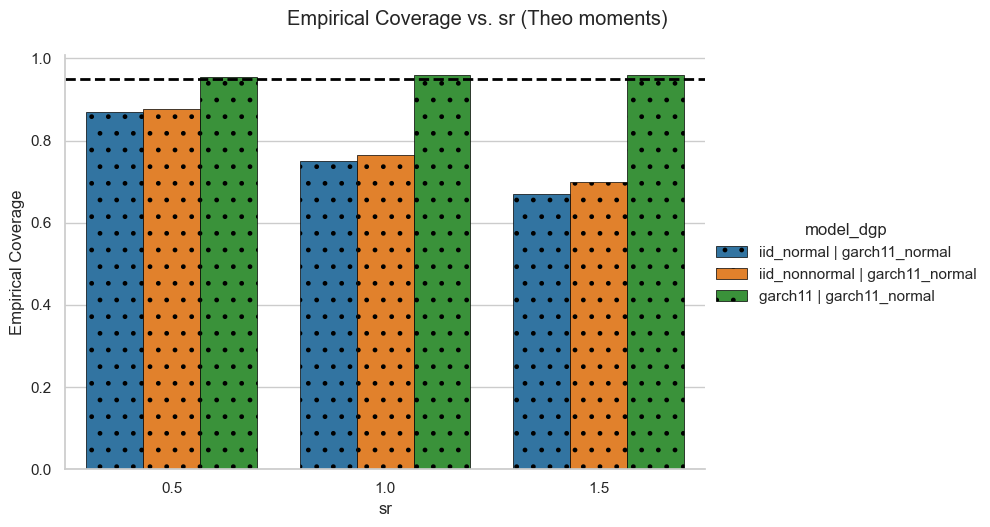

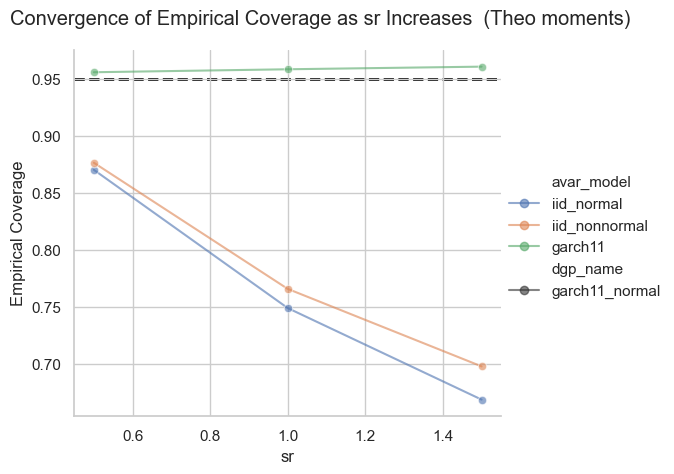

In [51]:
# "tails", "serial", "hetero_tails"

#filtered_dgps = ["iid_t5"]
#filtered_models = ["iid_normal", "iid_student_t", "iid_nonnormal"]
#filtered_dgps = ["ar1_phi06_normal", "ar1_phi-06_normal"]
#filtered_models = ["iid_normal", "ar1_normal"]
#filtered_dgps = ["garch11_normal"]
#filtered_models = ["iid_normal", "iid_nonnormal", "garch11"] 

idx = 2
pair_id, filtered_dgps, filtered_models = dgps_models[idx]
th_moments = not False

param_name, param_values = 'sr', [0.5, 1.0 , 1.5]
#param_name, param_values = 'T', [100, 500 , 2000]
#param_name, param_values = 'n_sim', [1_000, 10_000, 50_000]

run_analysis(param_name=param_name, param_values=param_values,
             filtered_dgps=filtered_dgps, filtered_models=filtered_models,
             target_coverage=target_coverage,
             prefix=pair_id + ("theo_" if th_moments else "_"),
             title="(Theo moments)" if th_moments else ""
             )

In [ ]:

filtered_dgps = ["iid_t5"]
filtered_models = ["iid_normal", "iid_student_t", "iid_nonnormal"]

filtered_dgps = ["ar1_phi06_normal", "ar1_phi-06_normal"]
filtered_models = ["iid_normal", "ar1_normal"]

es necesario garch?
filtered_dgps = ["garch11_normal"]
filtered_models = ["iid_normal", "iid_nonnormal", "garch11"] 
